# Matplotlib: Customization & Styling

The default matplotlib output is fine for quick exploration, but anything you intend to share — a report, a slide, a paper — needs deliberate styling. This notebook covers the controls matplotlib gives you for that: how to specify colors, map data onto color gradients, format the numbers on your axes, point at specific values with text and arrows, apply themes, manage fonts, and strip out the visual clutter that distracts from the data.

Topics covered:

1. **Colors** — the four equivalent ways matplotlib accepts a color (named, hex, RGB, cycle position).
2. **Colormaps** — mapping a continuous range of numbers onto a gradient of colors, used for heatmaps, scatter plots colored by a third variable, and contour plots.
3. **Tick labels** — controlling what appears on the axes: rotating dates, formatting large numbers with commas, replacing numeric ticks with category names.
4. **Annotations** — adding text and arrows directly onto a plot to call out a specific point or region.
5. **Style sheets** — applying a named theme (`'ggplot'`, `'seaborn-v0_8'`, `'dark_background'`, etc.) to change the look of every chart at once.
6. **Text and fonts** — setting font family, size, and weight for titles, labels, and tick text.
7. **Chart junk** — Edward Tufte's term for the borders, gridlines, and decorative elements that add visual weight without conveying information. Removing them is often the highest-impact change you can make.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

## Colors

Anywhere matplotlib takes a `color=` argument, it accepts the same value in four interchangeable forms. Knowing all four matters because you will encounter each in different situations: tutorials use named colors, brand guidelines hand you hex codes, scientific papers often specify RGB, and well-written code uses cycle positions so it adapts to whatever theme is active.

The four formats:

- **Named colors** — string names matplotlib recognises. This includes the full set of CSS color names (around 140 of them: `'salmon'`, `'darkslategray'`, `'mediumseagreen'`) plus eight single-letter shortcuts for the basics: `'b'` blue, `'g'` green, `'r'` red, `'c'` cyan, `'m'` magenta, `'y'` yellow, `'k'` black, `'w'` white.
- **Hex strings** — the `'#rrggbb'` format from CSS and design tools. Each pair is a hexadecimal byte (00–ff) for red, green, and blue. `'#1f77b4'` is matplotlib's default blue. You can also write `'#rrggbbaa'` to include alpha (transparency).
- **RGB tuples** — three floats between 0.0 and 1.0 for red, green, and blue intensity. Be careful with the range: matplotlib uses 0–1, not the 0–255 you see in most other tools. A fourth value adds alpha, so `(0.12, 0.47, 0.71, 0.5)` is matplotlib's default blue at 50% opacity.
- **Cycle positions** — the strings `'C0'` through `'C9'` refer to the first ten slots in the current color cycle. The actual color each one maps to depends on the active style sheet. Using `'C0'` instead of `'#1f77b4'` means your code automatically adapts when you switch themes.


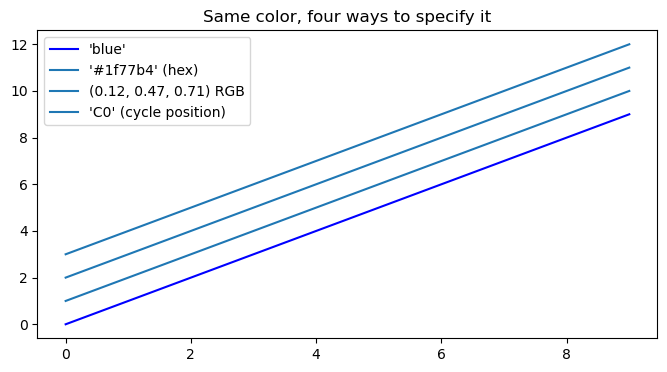

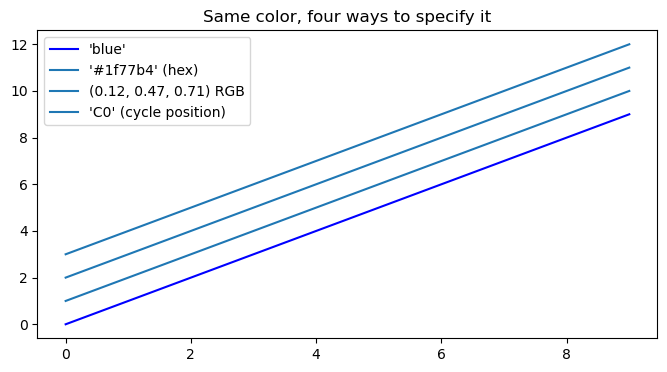

In [4]:
# All these specify the SAME color (matplotlib's default blue)
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(10)

ax.plot(x, x,        color='blue',        label="'blue'")
ax.plot(x, x + 1,    color='#1f77b4',     label="'#1f77b4' (hex)")
ax.plot(x, x + 2,    color=(0.12, 0.47, 0.71), label="(0.12, 0.47, 0.71) RGB")
ax.plot(x, x + 3,    color='C0',          label="'C0' (cycle position)")

ax.legend()
ax.set_title("Same color, four ways to specify it")
plt.show()

### Walking through the code

- `plt.subplots(figsize=(8, 4))` creates a figure (the whole canvas) and a single axes (the plotting area) in one call, returning both. `figsize` is given in inches and controls the canvas size; `(8, 4)` here means 8 inches wide by 4 tall.
- `ax.plot(x, y, color=..., label=...)` draws a line on the axes. The `color` argument is what this section is about — each of the four lines passes it in a different format. The `label` is the text that will appear in the legend for that line.
- `ax.legend()` looks at every artist on the axes that was given a `label`, collects them, and draws a legend box. With no arguments, matplotlib picks the corner with the least overlap.
- `ax.set_title(...)` puts text above the axes. The title font size and weight come from the active style sheet.
- `plt.show()` flushes the figure to the notebook output. In a script you would call this once at the end; in a notebook each cell that builds a figure typically ends with it.

### Choosing between formats

Use **named colors** for quick exploration and when you need a color you can describe in words. Use **hex** when matching a brand color or a palette from a design tool. Use **RGB tuples** when you need to compute a color programmatically — interpolating between two colors, or building one from saved numerical values. Use **cycle positions** in any code that should respect the active theme: library code, reusable plotting functions, and anything you want to restyle later without rewriting.

### A closer look at the default color cycle

The four formats above are about *how* you write a color. The next cell shows *which* colors matplotlib reaches for when you don't specify one at all.

Every axes carries a **property cycle** — an ordered list of styles matplotlib hands out, one per call, as you draw on it. The most visible part of that cycle is the color sequence. The default cycle (called `'tab10'`) has ten colors: a blue, an orange, a green, and so on. The strings `'C0'` through `'C9'` are explicit handles to those slots, so `color='C0'` means "give me whatever the first color in the active cycle is."

The cell below loops ten times and draws one line per cycle slot. Each line is offset vertically by `i` so they sit side by side instead of overlapping. The legend is placed below the axes (`bbox_to_anchor=(0.5, -0.05)`) with all ten entries on a single row (`ncol=10`) so you can read the names left to right.

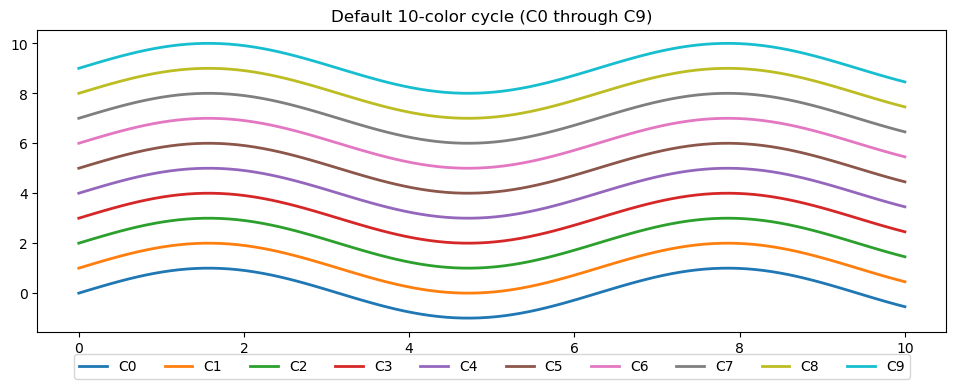

Saved color cycle


In [7]:
# The default color cycle
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(10):
    ax.plot(np.linspace(0, 10, 100), np.sin(np.linspace(0, 10, 100)) + i,
            color=f'C{i}', label=f'C{i}', linewidth=2)
ax.legend(ncol=10, loc='upper center', bbox_to_anchor=(0.5, -0.05))
ax.set_title("Default 10-color cycle (C0 through C9)")
plt.tight_layout()
plt.show()
fig.savefig('mpl3_cycle.png', dpi=80)
plt.close()
print("Saved color cycle")

**Reading the code:**

- `for i in range(10)` iterates over the ten slots `C0`–`C9`.
- `np.linspace(0, 10, 100)` makes 100 evenly spaced x-values; `np.sin(...) + i` shifts each sine wave up by `i` so the lines don't overlap.
- `color=f'C{i}'` is an f-string that turns the loop variable into the right cycle handle on each pass — `'C0'`, `'C1'`, and so on.
- `ax.legend(ncol=10, loc='upper center', bbox_to_anchor=(0.5, -0.05))` controls the legend layout. `ncol=10` says lay all entries out in a single horizontal row. `loc` picks an anchor point on the legend itself; `bbox_to_anchor` places that anchor in axes coordinates. `(0.5, -0.05)` is just below the bottom of the axes, centered horizontally.
- `plt.tight_layout()` adjusts the figure's internal spacing so the legend below the axes is not clipped when the figure is rendered or saved.

### Building a custom palette

A **palette** is a small, named set of colors you reuse across every chart in a project so the visual identity stays consistent. Reports, dashboards, and scientific papers all benefit from one: instead of picking whatever color feels right per plot, you decide once and reuse the names.

The usual structure is a Python dictionary mapping semantic names (`'primary'`, `'accent'`, `'highlight'`) to hex codes. Naming by *role* rather than by *color* matters — if you later swap "deep blue" for "deep green," you only change the value in one place and every chart updates automatically.

The cell below defines an ocean-themed palette of five colors and uses it on a bar chart: most bars in the primary blue, Thursday's bar in the highlight gold to draw the eye, and the title in the near-black `'text'` color. Two of the four axis spines (top and right) are turned off so the chart has less surrounding clutter — a preview of the "chart junk" section at the end of this notebook.

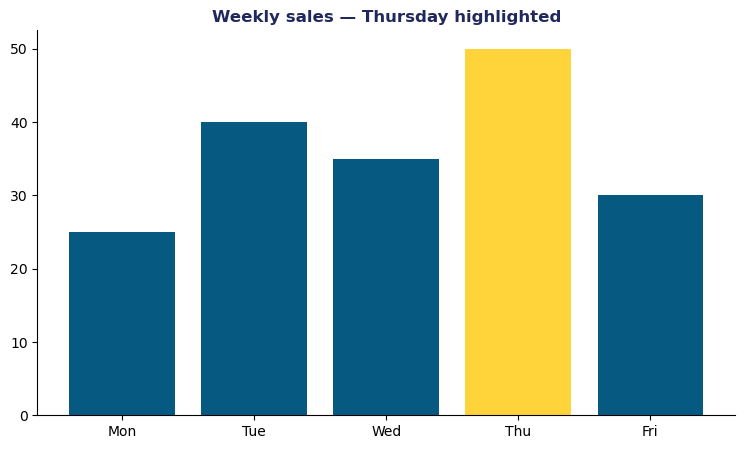

Saved custom palette plot


In [8]:
# A custom palette — ocean theme
PALETTE = {
    'primary':   '#065A82',  # deep blue
    'secondary': '#1C7293',  # teal
    'accent':    '#9EB3C2',  # muted blue-grey
    'highlight': '#FFD43B',  # gold
    'text':      '#21295C',  # near-black
}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(5)
heights = [25, 40, 35, 50, 30]
ax.bar(x, heights, color=PALETTE['primary'])

# Highlight one bar
ax.bar([3], [50], color=PALETTE['highlight'])

ax.set_xticks(x)
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
ax.set_title("Weekly sales — Thursday highlighted",
             color=PALETTE['text'], fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
fig.savefig('mpl3_palette.png', dpi=80)
plt.close()
print("Saved custom palette plot")

**Reading the code:**

- `ax.bar(x, heights, color=PALETTE['primary'])` draws all five bars in the primary color. `x` gives the horizontal position of each bar, `heights` their heights.
- `ax.bar([3], [50], color=PALETTE['highlight'])` draws a single bar on top of the existing one at position 3 in the highlight color. Drawing the highlight bar *after* the others matters — matplotlib renders later artists on top, so this one wins.
- `ax.set_xticks(x)` followed by `ax.set_xticklabels(['Mon', ...])` is the standard two-step for replacing numeric tick positions with custom text. You set the positions first, then the labels for those positions. (Doing only `set_xticklabels` without `set_xticks` is a common source of warnings, because matplotlib doesn't know which positions you mean.)
- `ax.set_title(..., color=..., fontweight='bold')` accepts a font color and weight directly. Anything you can set globally with a style sheet can also be set per call.
- `ax.spines['top'].set_visible(False)` removes the line that runs along the top edge of the axes. The four spines are `'top'`, `'bottom'`, `'left'`, `'right'`. Hiding `'top'` and `'right'` is the standard cleanup and almost always improves the look.

## Colormaps for Continuous Data

A **colormap** is a function that maps a number to a color. Instead of picking one color per line (as in the previous section), you hand matplotlib a whole array of numbers and it produces a gradient of colors covering them. This is how heatmaps, scatter plots colored by a third variable, contour plots, and any other "color = value" visualization is built.

There are three families of colormaps and choosing the wrong family is one of the most common ways to mislead the reader:

- **Sequential** — for data that goes from low to high with no special middle value. The colormap goes from a light/dark color through to its opposite. Examples: `'viridis'`, `'plasma'`, `'inferno'`, `'magma'`, `'Blues'`, `'Greys'`. Use these for any quantity where bigger means more of the same thing (temperature, count, intensity).
- **Diverging** — for data with a meaningful midpoint where direction matters either side of it. The colormap has two distinct colors at the ends and a neutral color in the middle. Examples: `'RdBu_r'`, `'coolwarm'`, `'RdYlBu_r'`. Use these for correlation matrices (−1 to +1), profit and loss (negative vs positive), or anomalies above/below a baseline.
- **Qualitative** — for categorical data where the numeric value is just a label, not a quantity. Adjacent values in the colormap are visually distinct rather than similar. Examples: `'tab10'`, `'tab20'`, `'Set1'`, `'Pastel1'`. Use these when coloring by category, not magnitude.

The cell below renders one example from each family as a horizontal strip so you can see the difference.

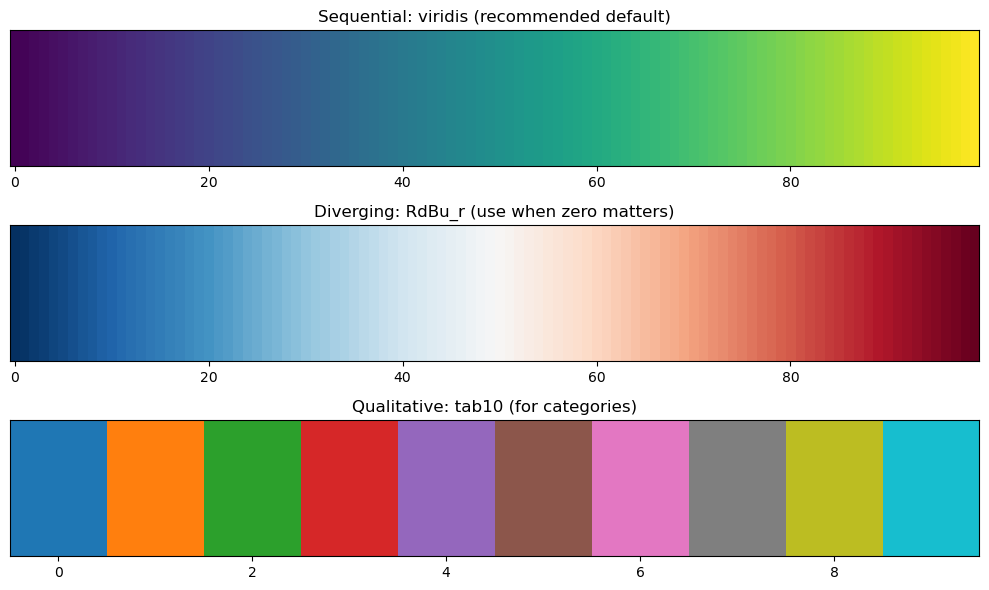

Saved colormap types


In [9]:
# Three categories of colormaps
fig, axes = plt.subplots(3, 1, figsize=(10, 6))

data = np.linspace(0, 1, 100).reshape(1, -1)

# Sequential — for data that goes from low to high
axes[0].imshow(data, aspect='auto', cmap='viridis')
axes[0].set_title("Sequential: viridis (recommended default)")
axes[0].set_yticks([])

# Diverging — for data with a meaningful middle (e.g., correlation -1 to +1)
axes[1].imshow(np.linspace(-1, 1, 100).reshape(1, -1), aspect='auto', cmap='RdBu_r')
axes[1].set_title("Diverging: RdBu_r (use when zero matters)")
axes[1].set_yticks([])

# Qualitative — for categorical data
axes[2].imshow(np.arange(10).reshape(1, -1), aspect='auto', cmap='tab10')
axes[2].set_title("Qualitative: tab10 (for categories)")
axes[2].set_yticks([])

plt.tight_layout()
plt.show()
fig.savefig('mpl3_cmaps.png', dpi=80)
plt.close()
print("Saved colormap types")

**Reading the code:**

- `plt.subplots(3, 1, figsize=(10, 6))` creates a figure with three axes stacked vertically: 3 rows, 1 column. `axes` is a NumPy array; `axes[0]` is the top strip, `axes[2]` is the bottom.
- `data = np.linspace(0, 1, 100).reshape(1, -1)` builds a 1×100 array of values from 0 to 1. `imshow` expects 2D input (it draws images), so `reshape(1, -1)` turns the flat array into a single row of 100 pixels. The `-1` in reshape means "fill in whatever dimension is needed."
- `imshow(data, aspect='auto', cmap='viridis')` draws the array as colored pixels. `aspect='auto'` lets the strip stretch to fill the axes box — without it, `imshow` keeps pixels square and the strip would be very thin and tall.
- `cmap=` is where the choice of colormap goes. Swap the string and the gradient changes.
- `axes[0].set_yticks([])` removes the y-axis ticks. The strips have only one row of data, so y values would just be noise.
- `plt.tight_layout()` ensures the three titles don't collide with the strip above them.

**Quick recommendations:**

| Data type | Use these colormaps |
|---|---|
| Sequential (low → high) | `viridis`, `plasma`, `inferno`, `magma` |
| Diverging (negative ← 0 → positive) | `RdBu_r`, `RdYlBu_r`, `coolwarm` |
| Categorical | `tab10`, `tab20`, `Set1`, `Set2` |
| Avoid (perceptually broken) | `jet`, `rainbow` |

**Why `viridis` is the default:** it's perceptually uniform (equal differences in value = equal differences in perceived color) AND colorblind-friendly. `jet`/`rainbow` are pretty but lie about the data.

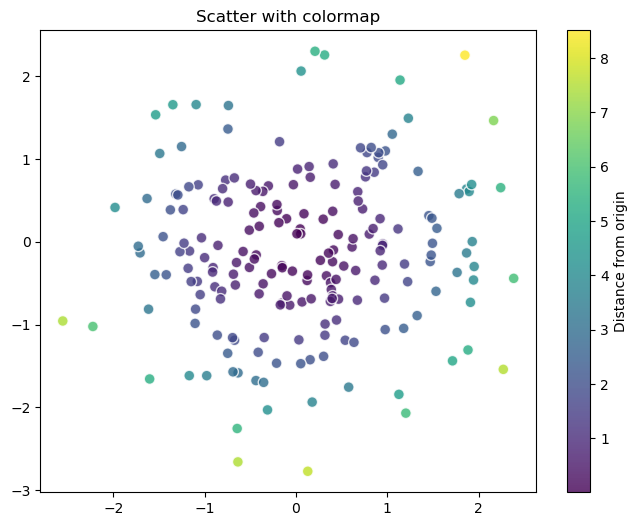

Saved scatter with colormap


In [11]:
# Using a colormap on a scatter plot
np.random.seed(0)
n = 200
x = np.random.randn(n)
y = np.random.randn(n)
values = x**2 + y**2   # distance from origin

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(x, y, c=values, cmap='viridis', s=60, alpha=0.8, edgecolors='white')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Distance from origin")
ax.set_title("Scatter with colormap")
plt.show()
fig.savefig('mpl3_scatter_cmap.png', dpi=80)
plt.close()
print("Saved scatter with colormap")

**Reading the scatter-plus-colormap pattern:**

This is the most common real use of colormaps. You have x, y, and a third variable; the third variable gets encoded as color.

- `np.random.randn(n)` draws `n` samples from a standard normal distribution (mean 0, standard deviation 1). Using `np.random.seed(0)` at the top makes the run reproducible.
- `values = x**2 + y**2` computes the squared distance from the origin for each point. This is the "third variable" that color will encode.
- `ax.scatter(x, y, c=values, cmap='viridis', ...)` is the key call. Note `c=values` (lowercase `c`), not `color=`. `color=` accepts a single color for all points; `c=` accepts an array of values that get passed through the colormap to produce a different color per point.
- `s=60` sets the marker size in points-squared; `alpha=0.8` makes them slightly transparent so overlapping points show through; `edgecolors='white'` outlines each marker, which makes them stand out when they overlap.
- `fig.colorbar(sc, ax=ax)` adds the vertical color-to-value legend on the right. It needs the scatter return value (`sc`) so it knows which colormap and value range to use, and `ax=ax` to know which axes to steal space from.
- `cbar.set_label("Distance from origin")` labels what the color means. Always label the colorbar — without it, the gradient is decorative rather than informative.

## Tick Labels and Formatting

The **ticks** are the marks along an axis where numbers (or labels) appear. By default matplotlib picks tick positions automatically and prints the raw numeric values. That's almost never what you want for a finished chart: the tick text might overlap, the units might be wrong (raw seconds when you wanted minutes), or the values might be meaningless without context (the number `0.05` instead of `5%`).

This section covers the three customizations you'll reach for most often:

- **Setting tick positions and text explicitly** — for axes that should show specific values like `0, π/2, π, 3π/2, 2π` instead of `0, 2, 4, 6`.
- **Rotating tick text** — for axes where the labels are long enough that horizontal text would overlap (city names, dates, file names).
- **Formatting numbers** — adding `$`, `%`, comma separators, or unit suffixes through a formatter object, without having to manually rewrite every value.

The same approach works for both axes; the methods just have `x` or `y` in the name.

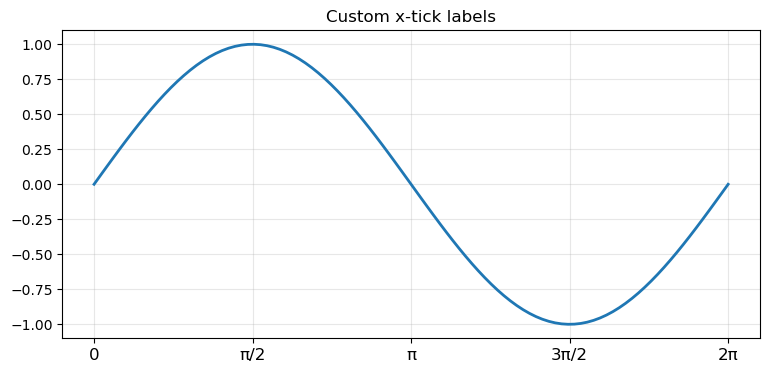

Saved custom ticks


In [12]:
# Custom tick positions and labels
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(0, 2*np.pi, 100)
ax.plot(x, np.sin(x), linewidth=2)

# Custom x-ticks at multiples of π/2
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'], fontsize=12)

ax.set_title("Custom x-tick labels")
ax.grid(True, alpha=0.3)
plt.show()
fig.savefig('mpl3_ticks.png', dpi=80)
plt.close()
print("Saved custom ticks")

**Reading the code:**

This is the explicit-positions pattern. You tell matplotlib both *where* to put ticks and *what text* to print at each one.

- `x = np.linspace(0, 2*np.pi, 100)` makes 100 evenly spaced x-values from 0 to 2π for the sine curve. The sine completes one full cycle over this range.
- `ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])` places ticks at the five values where the sine has a meaningful feature (zero, peak, zero, trough, zero). Matplotlib would otherwise place them at 0, 1, 2, ... 6, which has no relationship to the curve.
- `ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'], fontsize=12)` replaces the numeric values at those positions with mathematical notation. The list must be the same length as the positions list and in the same order.
- `ax.grid(True, alpha=0.3)` draws gridlines through the tick positions. `alpha=0.3` makes them faint enough to be a reference without competing with the curve itself.

The order matters: `set_xticks` first, then `set_xticklabels`. The labels list is interpreted relative to the positions you just set.

In [ ]:
# Rotating tick labels — useful when labels are long
fig, ax = plt.subplots(figsize=(9, 5))
cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 'San Antonio']
populations = [8.4, 4.0, 2.7, 2.3, 1.7, 1.6, 1.5]

ax.bar(cities, populations, color='steelblue')
ax.set_title("US city populations (millions)")
ax.set_ylabel("Population (M)")

# Rotate x-tick labels 45 degrees
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()
fig.savefig('mpl3_rotated.png', dpi=80)
plt.close()
print("Saved with rotated labels")


**Reading the code:**

When category labels are wider than the bars themselves, horizontal labels overlap or get truncated. Rotating them is the standard fix.

- `ax.bar(cities, populations, ...)` accepts a list of strings as the first argument; matplotlib treats each string as a category and gives it its own bar. The tick labels are set automatically from the strings.
- `plt.setp(ax.get_xticklabels(), rotation=45, ha='right')` is the rotation step. `ax.get_xticklabels()` returns the existing label objects, and `plt.setp` sets a property on every object in a sequence at once.
- `rotation=45` tilts the labels 45 degrees. 45° is the common choice; 30° is gentler, 90° is the most compact.
- `ha='right'` (horizontal alignment) anchors the labels at their right edge. This matters: without it, rotated labels stick out to the right of their bar and look misaligned. With `ha='right'`, the end of each label sits directly under its bar.
- `plt.tight_layout()` is essential after rotation. Rotated labels are taller than horizontal ones, and without `tight_layout` they get clipped by the figure edge.

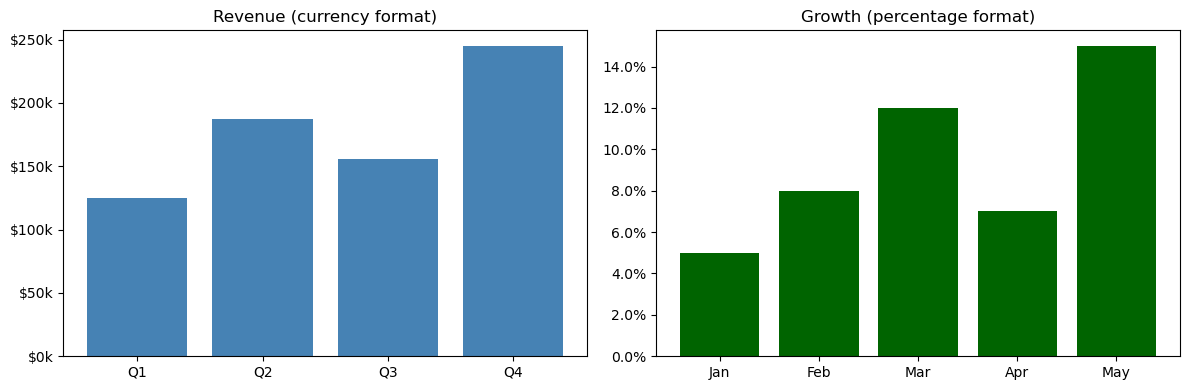

Saved formatted axes


In [13]:
# Formatting numbers — currency, percentages, etc.
from matplotlib.ticker import FuncFormatter, PercentFormatter

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Currency formatting
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
revenue = [125000, 187000, 156000, 245000]
axes[0].bar(quarters, revenue, color='steelblue')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_title("Revenue (currency format)")

# Percentage formatting
ax = axes[1]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
growth = [0.05, 0.08, 0.12, 0.07, 0.15]
ax.bar(months, growth, color='darkgreen')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Growth (percentage format)")

plt.tight_layout()
plt.show()
fig.savefig('mpl3_formatters.png', dpi=80)
plt.close()
print("Saved formatted axes")

**Reading the formatter pattern:**

The previous two examples replaced tick text directly. A **formatter** is the general mechanism behind that: instead of hand-writing every label, you give matplotlib a function (or a pre-built formatter object) and it calls that function for every tick. The label updates automatically if the data range changes.

- `from matplotlib.ticker import FuncFormatter, PercentFormatter` imports two formatter classes. `FuncFormatter` wraps any function you write. `PercentFormatter` is a pre-built one for percentages.
- `axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))` installs a custom formatter on the y-axis. The lambda receives two arguments — the tick value (`x`) and its index position (which we don't use, hence `_`) — and returns the string to display. So a tick value of `187000` becomes `'$187k'`.
- `axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))` installs the percentage formatter. The `1.0` argument tells it the value that should be displayed as `100%` — pass `1.0` when your data is in proportion form (0.0 to 1.0), or `100` when your data is already in percent form (0 to 100).
- `set_major_formatter` controls the labels at the major tick positions. There's also `set_minor_formatter` for the smaller in-between ticks, which are off by default.

The advantage over rewriting labels by hand: if you change your data range or matplotlib auto-picks different tick positions, the format follows automatically. You wrote the *rule*, not the *output*.

### Log-scale axes — when data spans many orders of magnitude

A **linear** axis places equal *differences* at equal distances: the gap from 1 to 2 is the same as the gap from 99 to 100. That works fine for data that varies within one order of magnitude, but as soon as your data ranges from 1 to 10,000 the small values are squashed into a thin band at the bottom of the plot and detail is lost.

A **logarithmic** axis places equal *ratios* at equal distances: the gap from 1 to 10 is the same as the gap from 10 to 100, which is the same as the gap from 100 to 1000. Each step represents multiplying by ten. This makes data that spans many orders of magnitude (populations, earthquake magnitudes, RNA expression levels, financial returns) readable across the whole range.

The cell below plots `y = x³` from 1 to 100. On the left, with a linear y-axis, the values from x=1 to x=20 are invisible. On the right, with a log y-axis, you can read the full curve. The data is identical; only the axis scale changed.

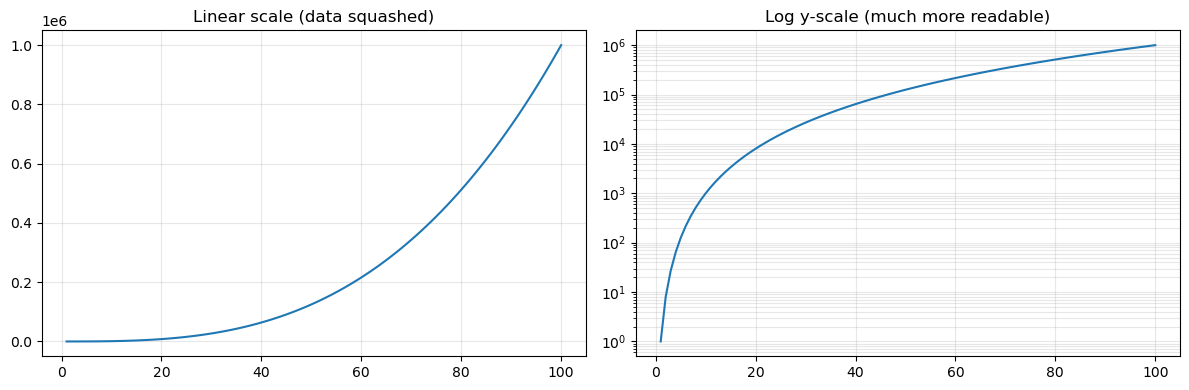

Saved log scale comparison


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(1, 100, 100)
y = x ** 3

# Linear scale — the early values are invisible
axes[0].plot(x, y)
axes[0].set_title("Linear scale (data squashed)")
axes[0].grid(True, alpha=0.3)

# Log scale — shows the full structure
axes[1].plot(x, y)
axes[1].set_yscale('log')
axes[1].set_title("Log y-scale (much more readable)")
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
fig.savefig('mpl3_logscale.png', dpi=80)
plt.close()
print("Saved log scale comparison")

**Reading the code:**

- `axes[1].set_yscale('log')` is the only line that does the work. Matplotlib reroutes all subsequent rendering on that axis through a log transform, and the tick positions and grid update automatically.
- `'log'` defaults to base 10. Pass `set_yscale('log', base=2)` for a binary scale.
- `set_xscale('log')` works the same way. You can have one or both axes logarithmic — both is called a "log-log plot" and is the standard way to look at power-law relationships.
- `ax.grid(True, alpha=0.3, which='both')` is worth noting: `which='both'` draws gridlines at both the major ticks (1, 10, 100) and the minor ticks (2, 3, ..., 9 inside each decade). On a log axis, those minor gridlines are what let you read intermediate values; without them you can only see decade boundaries.

A caveat: log scales cannot show zero or negative values. If your data includes them, matplotlib will silently leave them out or warn you. For data that crosses zero, use `set_yscale('symlog')` instead — it's linear near zero and logarithmic further out.

## Annotations — Pointing Things Out

An **annotation** is text (often with an arrow) placed directly on the plot to call out a specific point or region. The reader's eye is drawn to it without having to cross-reference a caption or a legend.

There are two related but distinct methods you'll use:

- `ax.text(x, y, "...")` — drops free-floating text at coordinates `(x, y)`. Use it when you want a label sitting somewhere on the plot with no arrow attached. The coordinates are in **data units** by default (the same units as your x and y axis), but you can switch to **axes coordinates** (0 to 1 across the plot regardless of data range) with `transform=ax.transAxes`. Axes coordinates are useful for "always put this in the top-left corner" regardless of what data you're plotting.
- `ax.annotate("...", xy=..., xytext=...)` — draws text *and* a connecting arrow. `xy` is the point the arrow points *to*; `xytext` is where the text itself sits. The `arrowprops` dictionary controls the arrow's style.

For shading whole regions (not a single point), `axvspan(x1, x2)` draws a vertical stripe between two x-values and `axhspan(y1, y2)` does the same horizontally. These are good for marking "during this period" or "above this threshold" on a chart.

The two cells below cover both patterns: an arrow pointing to the peak of a curve, and a shaded region marking an event window on a time series.

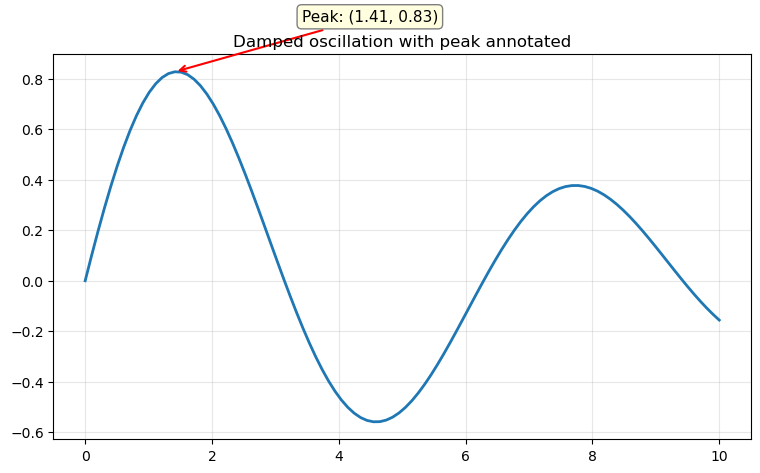

Saved annotation example


In [15]:
# Simple text annotation
fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(0, 10, 100)
y = np.sin(x) * np.exp(-x/8)
ax.plot(x, y, linewidth=2)

# Find the peak
peak_idx = np.argmax(y)
peak_x, peak_y = x[peak_idx], y[peak_idx]

# Annotation with arrow
ax.annotate(
    f'Peak: ({peak_x:.2f}, {peak_y:.2f})',
    xy=(peak_x, peak_y),                      # point to annotate
    xytext=(peak_x + 2, peak_y + 0.2),         # where the text goes
    fontsize=11,
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

ax.set_title("Damped oscillation with peak annotated")
ax.grid(True, alpha=0.3)
plt.show()
fig.savefig('mpl3_annotation.png', dpi=80)
plt.close()
print("Saved annotation example")

**Reading the annotation code:**

The curve is a damped oscillation — a sine wave whose amplitude shrinks over time. We want to label its highest point.

- `y = np.sin(x) * np.exp(-x/8)` is the damped oscillation. `np.exp(-x/8)` is a decaying envelope; multiplying it into `np.sin(x)` produces the gradually shrinking wiggle.
- `peak_idx = np.argmax(y)` finds the index of the largest y-value. `np.argmax` returns the *position* of the maximum, not the maximum itself.
- `peak_x, peak_y = x[peak_idx], y[peak_idx]` looks up the x and y coordinates at that position. Now we know exactly where to point.
- `ax.annotate(text, xy=..., xytext=..., arrowprops=..., bbox=...)` does the actual annotation. Six things to notice:
  - The text itself is an f-string that drops the peak coordinates into the label.
  - `xy=(peak_x, peak_y)` is the arrow's target — the tip lands here.
  - `xytext=(peak_x + 2, peak_y + 0.2)` is where the text sits — two units to the right and a bit above the peak, so the text doesn't cover the curve.
  - `arrowprops=dict(arrowstyle='->', color='red', lw=1.5)` styles the arrow. `arrowstyle='->'` is the standard arrow shape; matplotlib supports many others (`'-|>'`, `'fancy'`, `'wedge'`).
  - `bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')` puts a rounded yellow box behind the text. The padding (`pad=0.3`) gives a small margin between the text and the box edge.

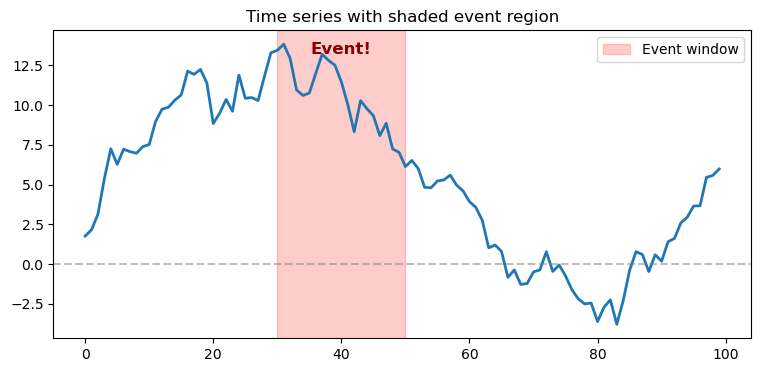

Saved shaded region


In [16]:
# Highlighting a region with axvspan / axhspan
fig, ax = plt.subplots(figsize=(9, 4))
np.random.seed(0)
x = np.arange(100)
y = np.cumsum(np.random.randn(100))
ax.plot(x, y, linewidth=2)

# Shade a region of interest (e.g., during an event)
ax.axvspan(30, 50, alpha=0.2, color='red', label='Event window')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Annotate the event
ax.text(40, ax.get_ylim()[1] * 0.9, 'Event!', ha='center',
        fontsize=12, fontweight='bold', color='darkred')

ax.set_title("Time series with shaded event region")
ax.legend()
plt.show()
fig.savefig('mpl3_span.png', dpi=80)
plt.close()
print("Saved shaded region")

**Reading the shaded-region code:**

- `y = np.cumsum(np.random.randn(100))` simulates a random walk: 100 normal samples summed cumulatively. The result drifts up and down like a price series.
- `ax.axvspan(30, 50, alpha=0.2, color='red', label='Event window')` shades everything between x=30 and x=50 in faint red. The `alpha=0.2` is essential — without transparency the band would hide the curve underneath. The `label` makes the band appear in the legend.
- `ax.axhline(0, color='gray', linestyle='--', alpha=0.5)` draws a horizontal dashed line at y=0. This is a reference line — the eye uses it to judge whether the random walk is above or below its starting level. `axhline` (horizontal) and `axvline` (vertical) are the single-line versions of the span methods.
- `ax.text(40, ax.get_ylim()[1] * 0.9, 'Event!', ...)` places a label near the top of the shaded band.
  - The x-coordinate `40` is the middle of the band (`30` + `50`)/2.
  - The y-coordinate `ax.get_ylim()[1] * 0.9` looks up the current top of the y-axis and goes 10% below it. This makes the label position responsive to whatever range the data ends up using.
  - `ha='center'` centers the text horizontally around x=40 (rather than starting from x=40 and extending right).

## Style Sheets — Instant Theming

A **style sheet** is a named collection of default values for every visual property: figure background, axes colors, font sizes, gridline weight, line thickness, the color cycle, and so on. Applying one with `plt.style.use('name')` rewrites the defaults all at once, so every plot you draw afterwards adopts the new look without you touching any individual call.

Matplotlib ships with dozens of style sheets. The ones you'll reach for most:

- `'default'` — matplotlib's plain defaults. The white background, blue lines, thin spines.
- `'seaborn-v0_8'`, `'seaborn-v0_8-darkgrid'`, `'seaborn-v0_8-whitegrid'` — clean, modern look inspired by the seaborn library. Soft palettes and a light grey grid by default. (The `v0_8` in the name is because matplotlib froze this style at seaborn version 0.8 to keep it stable.)
- `'ggplot'` — the gridded look from R's ggplot2: grey panel backgrounds, white gridlines.
- `'fivethirtyeight'` — the bold, blog-ready style from the FiveThirtyEight data journalism site: large fonts, thick lines, muted colors.
- `'dark_background'` — for slide decks with dark themes.
- `'classic'` — matplotlib's pre-2.0 look, mostly here for nostalgia and reproducing old papers.

The next three cells: a directory listing of every available style, a side-by-side comparison of four of them, and the recommended usage pattern (set the style once at the top of your script, not per plot).

In [17]:
# Show what styles are available
print("Built-in styles:")
for style in plt.style.available[:15]:
    print(f"  - {style}")
print(f"  ... and {len(plt.style.available) - 15} more")

Built-in styles:
  - Solarize_Light2
  - _classic_test_patch
  - _mpl-gallery
  - _mpl-gallery-nogrid
  - bmh
  - classic
  - dark_background
  - fast
  - fivethirtyeight
  - ggplot
  - grayscale
  - seaborn-v0_8
  - seaborn-v0_8-bright
  - seaborn-v0_8-colorblind
  - seaborn-v0_8-dark
  ... and 13 more


`plt.style.available` is a list of strings — every style name matplotlib knows about, including any third-party styles you've installed. The cell prints the first 15 and tells you how many more exist. To use any of them, pass the string to `plt.style.use(...)` in the next cells.

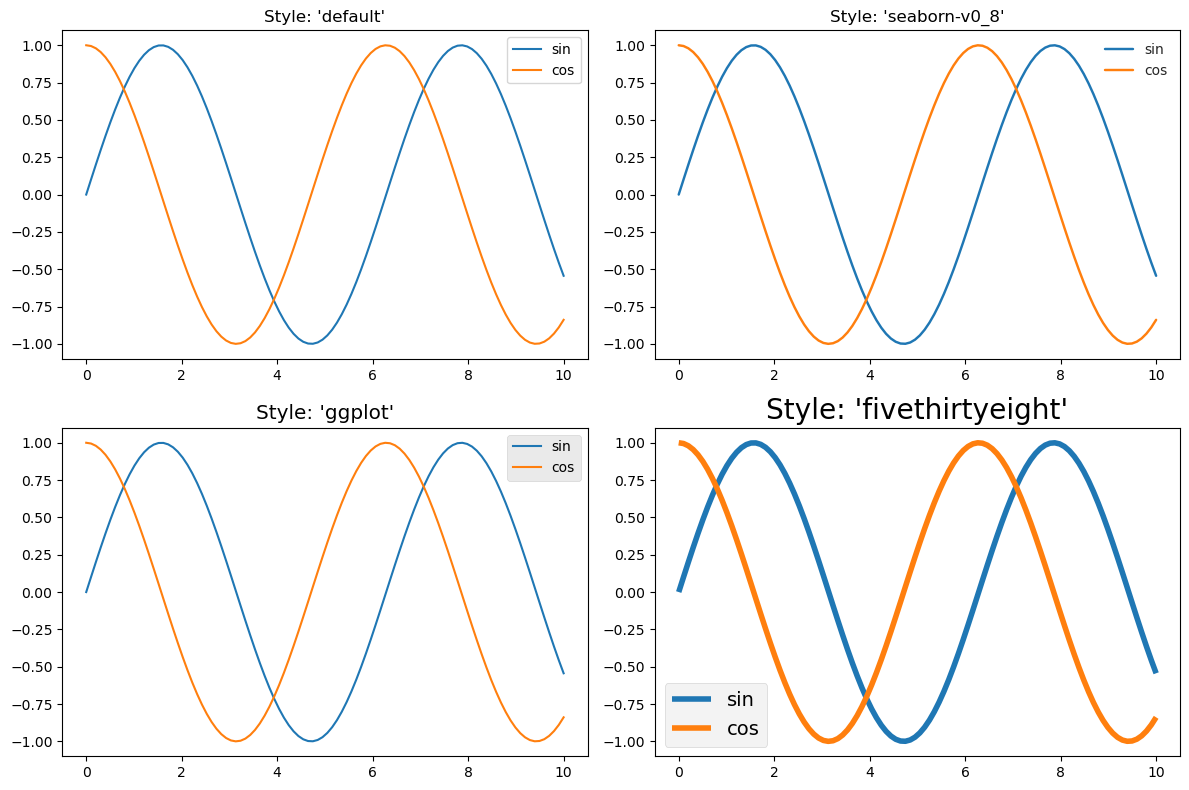

Saved style comparison


In [18]:
# Compare a few styles
styles_to_show = ['default', 'seaborn-v0_8', 'ggplot', 'fivethirtyeight']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x = np.linspace(0, 10, 100)

for ax, style in zip(axes.flat, styles_to_show):
    with plt.style.context(style):
        # We have to re-create the plot inside the context for the style to apply
        # But because we already have an ax, we'll do this differently:
        ax.plot(x, np.sin(x), label='sin')
        ax.plot(x, np.cos(x), label='cos')
        ax.set_title(f"Style: '{style}'")
        ax.legend()

# Note: style.context doesn't apply to pre-existing axes very well.
# In real use, set the style ONCE at the top of your script.
plt.tight_layout()
plt.show()
fig.savefig('mpl3_styles.png', dpi=80)
plt.close()
print("Saved style comparison")

**Reading the comparison code:**

- `plt.style.context(style)` is a *context manager* — it temporarily applies a style, runs the indented block, then restores the previous settings. The `with` block scopes the style change to a small region of code, so you can preview several styles in the same script without polluting the rest.
- The big caveat (called out in the comment in the cell): styles are applied to figures and axes *when they're created*. The figure and axes here were created before the `with` block, so the style change only catches a few late-stage settings like the legend's appearance — not the full visual switch.
- This is why the next cell shows the correct pattern: `plt.style.use(...)` at the top of the script, *before* creating any figures. The comparison code is here for illustration, not as a recommended pattern.

If you want a true side-by-side, create each figure inside its own `with plt.style.context(...)` block.

In [ ]:
# The right way to use styles — set globally at the top
plt.style.use('seaborn-v0_8-darkgrid')

fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), label='sin')
ax.plot(x, np.cos(x), label='cos')
ax.set_title("Plot using seaborn-v0_8-darkgrid style")
ax.legend()
plt.show()
fig.savefig('mpl3_styled.png', dpi=80)
plt.close()

# Reset to default for the rest of the notebook
plt.style.use('default')
print("Saved styled plot")

**Reading the recommended pattern:**

- `plt.style.use('seaborn-v0_8-darkgrid')` is called *before* any figure is created. This rewrites the global defaults. Every figure and axes created from this point on inherits the seaborn-darkgrid look.
- The figure built afterwards picks up the style automatically — notice the code doesn't set any colors, font sizes, or grid styles by hand.
- `plt.style.use('default')` at the bottom resets everything back to matplotlib defaults so the rest of the notebook is unaffected. This is the same trick the cell uses: change once, use, change back. In a real script you'd just leave the style set.

This is the pattern to follow in your own work: pick a style, set it once at the top, then write plotting code that only specifies the data — the look is already decided.

**Some recommendations:**

- `'seaborn-v0_8'` — clean, modern default
- `'seaborn-v0_8-darkgrid'` — same with grids (great for data exploration)
- `'fivethirtyeight'` — bold, blog-ready
- `'ggplot'` — R-style, popular in academia
- `'classic'` or `'default'` — Matplotlib's clean defaults



## Text and Fonts

Every visible piece of text in a matplotlib figure — title, axis labels, tick labels, legend entries, annotations — is an object you can style. The same handful of keyword arguments control all of them:

- `fontsize` — size in points. Numbers (`12`, `14`, `18`) or relative strings (`'small'`, `'medium'`, `'large'`, `'x-large'`).
- `fontweight` — `'normal'`, `'bold'`, or numeric weights `100`–`900` (where `400` is normal and `700` is bold).
- `fontfamily` — `'serif'`, `'sans-serif'`, `'monospace'`, or a specific font name like `'Arial'`.
- `fontstyle` — `'normal'`, `'italic'`, or `'oblique'`.
- `color` — accepts any of the four color formats from the Colors section.
- `pad` — extra space (in points) between the text and the axes edge. Used on titles to give them breathing room.

A separate concept worth knowing about is the **transform**: every text object can be placed in different coordinate systems. The default is data coordinates (the same units as your axis), but `transform=ax.transAxes` switches to axes coordinates that run from `(0, 0)` at the bottom-left of the plot to `(1, 1)` at the top-right, regardless of what data is plotted. This is the trick for "put this label in the corner" regardless of axis range.

The cell below uses all of these on a single plot: a bold dark-blue title with extra padding, custom axis labels, and a free-floating note pinned to the top-left in axes coordinates.

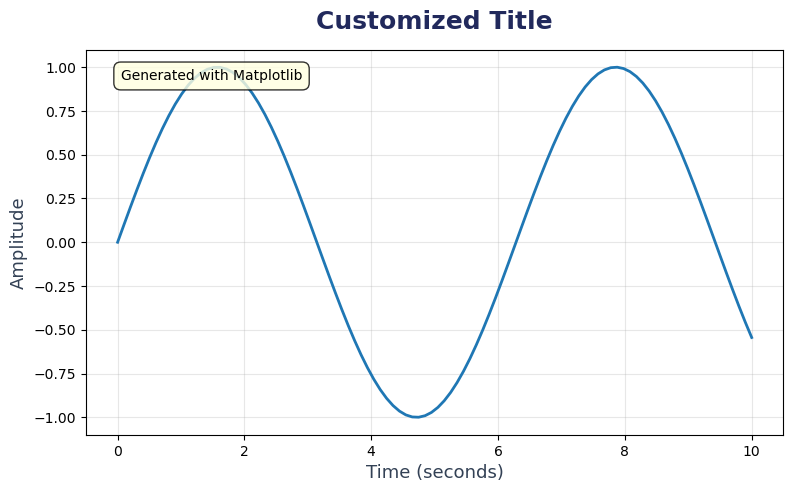

Saved with custom text


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), linewidth=2)

# Title with control over font
ax.set_title("Customized Title",
             fontsize=18, fontweight='bold',
             color='#21295C', pad=15)

# Labels with custom font
ax.set_xlabel("Time (seconds)", fontsize=13, color='#334155')
ax.set_ylabel("Amplitude", fontsize=13, color='#334155')

# Add a free-form text box anywhere
ax.text(0.05, 0.95, 'Generated with Matplotlib',
        transform=ax.transAxes,    # 'transAxes' = relative coords (0-1)
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

ax.grid(True, alpha=0.3)
plt.show()
fig.savefig('mpl3_text.png', dpi=80)
plt.close()
print("Saved with custom text")

**Reading the code:**

- `ax.set_title("...", fontsize=18, fontweight='bold', color='#21295C', pad=15)` — the title is bold, 18 points, in a dark navy hex color, with 15 points of padding between it and the top of the axes. The padding prevents the title from sitting flush against the plot area.
- `ax.set_xlabel(...)` and `ax.set_ylabel(...)` accept the same arguments. They're set to 13 points (a step down from the title) in a slightly lighter grey, so the visual hierarchy reads as title → labels → tick text.
- `ax.text(0.05, 0.95, 'Generated with Matplotlib', transform=ax.transAxes, ...)` is the in-corner note. Three things to notice:
  - The coordinates `(0.05, 0.95)` are interpreted in axes coordinates because of `transform=ax.transAxes`. `0.05` is 5% in from the left edge; `0.95` is 5% down from the top.
  - `verticalalignment='top'` anchors the text by its top edge rather than its baseline, so the box sits where you'd expect from the y-coordinate.
  - The `bbox` dictionary draws a rounded, semi-transparent yellow background behind the text. `alpha=0.8` lets the gridlines show faintly through.

The two reasons to use axes coordinates here rather than data coordinates: the note stays in the same visual spot if the data range changes, and you don't have to compute coordinates from the data each time you reuse the snippet.

## Removing Chart Junk

"Chart junk" is a term coined by Edward Tufte for anything in a chart that doesn't carry information — heavy borders, dense gridlines, decorative shading, redundant tick marks, 3D effects on bar charts. Each piece of chart junk adds visual weight that competes with the data, making the chart harder to read.

The default matplotlib output is functional but contains several pieces of chart junk: all four axes spines are drawn even though the top and right ones rarely carry meaning, ticks point both inward and outward, the gridlines are at full intensity, and on a bar chart the y-axis duplicates information you could put directly on the bars.

The cell below shows a before-and-after comparison side by side. Both panels display the same data — the difference is purely cosmetic. The right-hand panel applies these reductions:

1. **Hide top and right spines.** The data doesn't extend to those edges; the lines there only frame the chart.
2. **Lighten the remaining spines.** Light grey gives the same boundary effect with less ink.
3. **Drop the x-axis gridlines** (vertical gridlines through bars are noise) and keep only faint horizontal y-gridlines.
4. **Put gridlines behind the bars** with `set_axisbelow(True)`. By default gridlines are drawn on top of artists, which makes bars look striped.
5. **Label bars directly with their values** and remove the y-axis entirely. For small datasets, exact numbers on each bar are more useful than a scale to estimate from.

After the comparison there's a checklist you can apply to any plot.

In [ ]:
# Before — busy default
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = ['A', 'B', 'C', 'D', 'E']
values = [23, 45, 56, 32, 67]

# Busy
ax = axes[0]
ax.bar(categories, values, color='steelblue', edgecolor='black')
ax.set_title("Default — kind of busy")
ax.set_ylabel("Value")
ax.grid(True)
# All four spines, ticks everywhere — chart junk

# Clean
ax = axes[1]
ax.bar(categories, values, color='steelblue')
ax.set_title("Cleaner version", fontweight='bold')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lighter remaining spines
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

# Only y-axis grid, very subtle
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)  # grid behind bars

# Tick marks only on the bottom and left
ax.tick_params(top=False, right=False)

# Add value labels on bars (removes the need for y-axis)
for i, v in enumerate(values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

# Remove y-axis ticks since we have labels
ax.set_yticks([])
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig('mpl3_clean.png', dpi=80)
plt.close()
print("Saved before/after comparison")

**Reading the cleanup code (right-hand panel):**

The left panel uses defaults; everything new is in the right panel.

- `ax.spines['top'].set_visible(False)` and `ax.spines['right'].set_visible(False)` remove the two redundant border lines. The bottom and left spines stay because they anchor the tick labels.
- `ax.spines['left'].set_color('#888888')` and the matching `'bottom'` call swap the remaining spines from default black to a medium grey. This is one notch of reduced visual weight that adds up.
- `ax.yaxis.grid(True, alpha=0.3)` turns on horizontal gridlines only, at 30% opacity. `ax.xaxis.grid(False)` is implicit — we only enabled the y direction. The faint horizontal lines act as quiet reference rails without competing with the bars.
- `ax.set_axisbelow(True)` is easy to miss but matters. Without it, the gridlines are drawn on top of the bars, slicing them visually. With it, the grid is rendered first and the bars sit cleanly on top.
- `ax.tick_params(top=False, right=False)` removes the small tick marks from the top and right edges. With those spines hidden the ticks would float in mid-air, so they need to go too.
- The `for i, v in enumerate(values)` loop runs `ax.text(i, v + 1, str(v), ha='center', fontweight='bold')` once per bar. It places the bar's height value just above the bar (offset of `+1` on the y-axis), horizontally centered. `enumerate` gives both the bar's index (which is also its x-position) and its value.
- `ax.set_yticks([])` and `ax.spines['left'].set_visible(False)` finish the job: with values written on the bars there's no need for a y-axis scale at all, so the ticks and the left spine both go.

Each individual removal is small. The combined effect is the difference between a chart that asks the reader to ignore decorations and one that just shows the data.